In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter
import time



In [3]:
# Setting for the the trianing 
tr_percentage = 0.005 # train on provided percetage of data from the entire dataset
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: [{device}]")
print(f'Your are using {tr_percentage*100}% of your dataset')

Using device: [mps]
Your are using 0.5% of your dataset


In [4]:
# Prepare the dataset directories 
data_path = "food-classification/ifood-2019-fgvc6"
train_data = os.path.join(data_path, 'train_set')
test_data = os.path.join(data_path, 'val_set')

train_imgs = os.listdir(train_data) # get all training images files
test_imgs = os.listdir(test_data) # get all training images files
print(f'There are {len(train_imgs)} training and {len(test_imgs)} testing images')

There are 118475 training and 11994 testing images


In [5]:
# read the labels 
pdf = pd.read_csv(os.path.join(data_path, 'train_labels.csv'))
t_pdf = pd.read_csv(os.path.join(data_path, 'val_labels.csv'))
print(f'Ther are {pdf.isna().sum().sum()} images without labels')
pdf.count()

Ther are 0 images without labels


img_name    118475
label       118475
dtype: int64

In [6]:
# read the classes value
data_classes = pd.read_csv(os.path.join(data_path, 'class_list.txt'), sep=' ') 
data_classes.columns = ['id', 'name']
NUM_CLASSES = len(data_classes)+1
print(f'There are {NUM_CLASSES} classes')
data_classes, NUM_CLASSES

There are 251 classes


(      id                 name
 0      1              beignet
 1      2              cruller
 2      3          cockle_food
 3      4               samosa
 4      5             tiramisu
 ..   ...                  ...
 245  246  chicken_cordon_bleu
 246  247          eccles_cake
 247  248      moo_goo_gai_pan
 248  249         buffalo_wing
 249  250       stuffed_tomato
 
 [250 rows x 2 columns],
 251)

In [7]:
# plot the class distribution
def plot_class_distributions(num_labels, percentage = 100):
    """
    This method will plot the labels distribution passed in the histogram format
    """
    counts = Counter(num_labels)
    min_class = min(counts, key=counts.get)
    max_class = max(counts, key=counts.get)

    print(f"""
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)

    plt.figure(figsize=(12, 5))
    plt.hist(num_labels, bins=251, color='skyblue', edgecolor='black', alpha=0.8)
    plt.title(f"""
        Distribution of {percentage}% Labels
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)
    plt.xlabel('Label Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [8]:
# plot the all class distributions 
all_classes = pdf['label']


        Min class: 162  ––> 34 images
        Max class: 218 ––> 656 images 
    


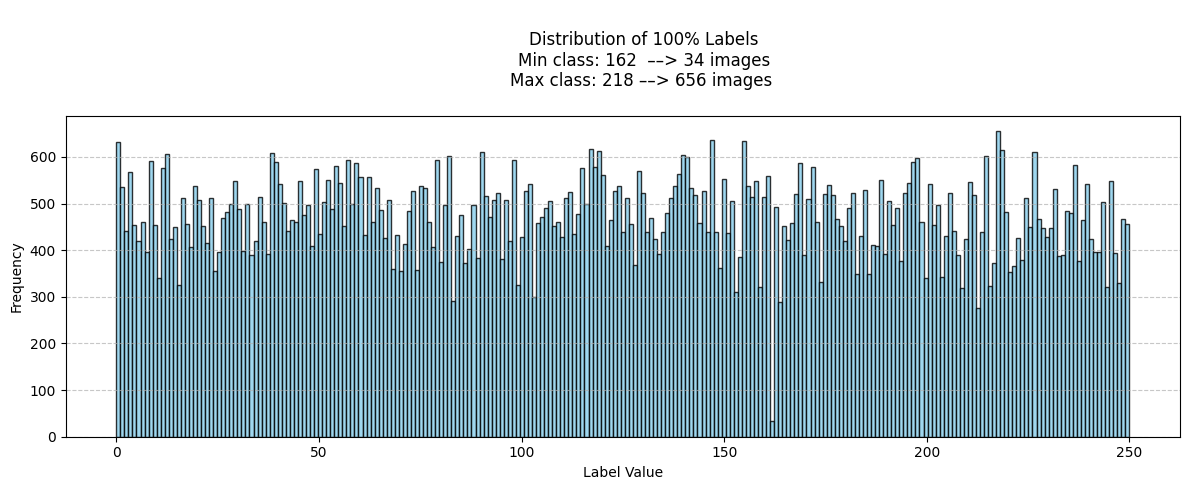

In [8]:
plot_class_distributions(all_classes)

In [9]:
# Stratified sampling to get xx% from each class
trainable_pdf = pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
test_pdf = t_pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)


        Min class: 83  ––> 1 images
        Max class: 0 ––> 3 images 
    


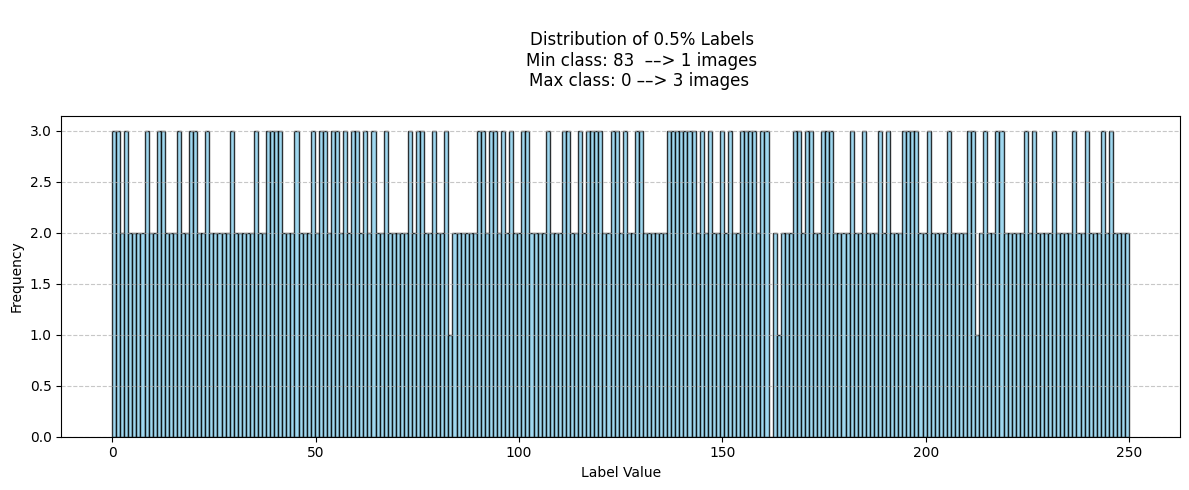

In [10]:
# plot the sampled classes destribution
plot_class_distributions(trainable_pdf['label'], tr_percentage*100)

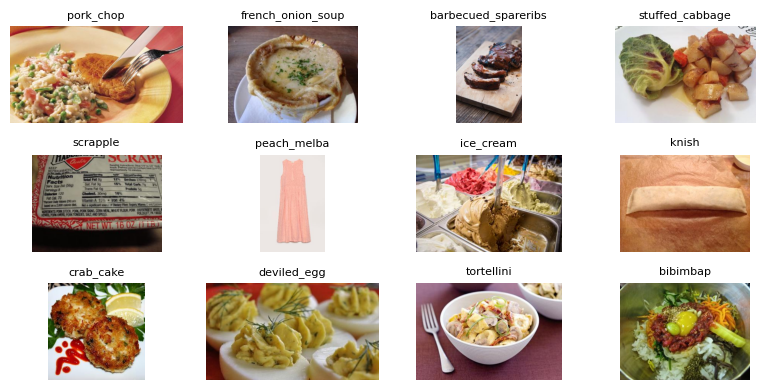

In [11]:
plt.figure(figsize=(8, 4))

for i in range(12): 
    plt.subplot(3, 4, i + 1)
    
    rand_idx = np.random.randint(len(trainable_pdf))
    rand_pdf = trainable_pdf[rand_idx-1:rand_idx]
    img_name = rand_pdf['img_name'].values[0]
    label = rand_pdf['label'].values[0]
    
    img = Image.open(os.path.join(data_path, 'train_set', img_name))
    plt.imshow(img)
    
    title_text = data_classes.iloc[label-1:label]['name'].values[0]
    plt.title(title_text, fontsize=8)
    
    plt.axis('off')

plt.tight_layout()
plt.show()


In [12]:
# Get the Mean and Std of the training dataset 
# This might take arround 8.5 minutes since I am calculating over the entire dataset
pixel_sum = np.zeros(3) # For RGB sum
pixel_sq_sum = np.zeros(3) 
total_pixels = 0

# this the final values after executing the loop 
# glb_mean = [162.75951001, 138.58583393, 113.06651858]
# glb_std = [70.29061983, 74.10972917, 80.80873226]

# Un comment this if you want to recalculate
# for img_name in train_imgs: 
#     # open image and convert to array format
#     img = np.array(Image.open(os.path.join(data_path, 'train_set', img_name))).astype(np.float32)

#     num_pixels = img.shape[0]*img.shape[1] # get the number of pixels of height and width
#     total_pixels += num_pixels # count the pixels 

#     # Sum pixels per chanel 
#     pixel_sum += np.sum(img, axis=(0, 1))
#     pixel_sq_sum += np.sum(img ** 2, axis=(0, 1))

# # final calucation 
# glb_mean = pixel_sum / total_pixels
# glb_var = (pixel_sq_sum / total_pixels) - (glb_mean ** 2)
# glb_std = np.sqrt(glb_var)
# print(glb_var)
# print("Dataset Mean (R, G, B):", glb_mean)
# print("Dataset Std  (R, G, B):", glb_std)

In [11]:
glb_mean = [162.75951001, 138.58583393, 113.06651858]
glb_std = [70.29061983, 74.10972917, 80.80873226]


In [12]:
class Myclass(Dataset):
    def __init__(self, df, dir='train_set', transform=None):
        super().__init__()
        self.df = df 
        self.dir = dir # images directory
        self.transform = transform 
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        file = self.df.iloc[idx].values
        img_name = file[0]
        label = file[1]
        img = Image.open(os.path.join(data_path, self.dir, img_name))
        if self.transform:
            img = self.transform(img)
        return img, label

In [13]:
# Create training and validation transform pipeline 
SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomRotation(10),
    # transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
    #crops a random portion of an image, resizes it, and alters its aspect ratio
    # transforms.RandomResizedCrop(80, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])
val_transform = transforms.Compose([  
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std =glb_std),
])

In [14]:
# split the train dataset in training (80%), validation (20%)
generator = torch.Generator().manual_seed(0) # keep the randomnes constant for the development and testing
indices = torch.randperm(len(trainable_pdf), generator=generator)

train_size = int(0.8 * len(trainable_pdf))

train_idx = indices[:train_size]
val_idx = indices[train_size:]
training_df = trainable_pdf.iloc[train_idx.tolist()].reset_index(drop=True)
validation_df = trainable_pdf.iloc[val_idx.tolist()].reset_index(drop=True)

print(f'{len(training_df)} images for training \n{len(validation_df)} images for validation \n{len(test_pdf)} images for testinng.')

477 images for training 
120 images for validation 
0 images for testinng.


In [15]:
# Get the training, Validation and testing datas
train_data = Myclass(training_df, 'train_set', train_transform)
val_data = Myclass(validation_df, 'train_set', val_transform)
test_data = Myclass(test_pdf, 'val_set', val_transform)
len(train_data), len(val_data), len(test_data)

(477, 120, 0)

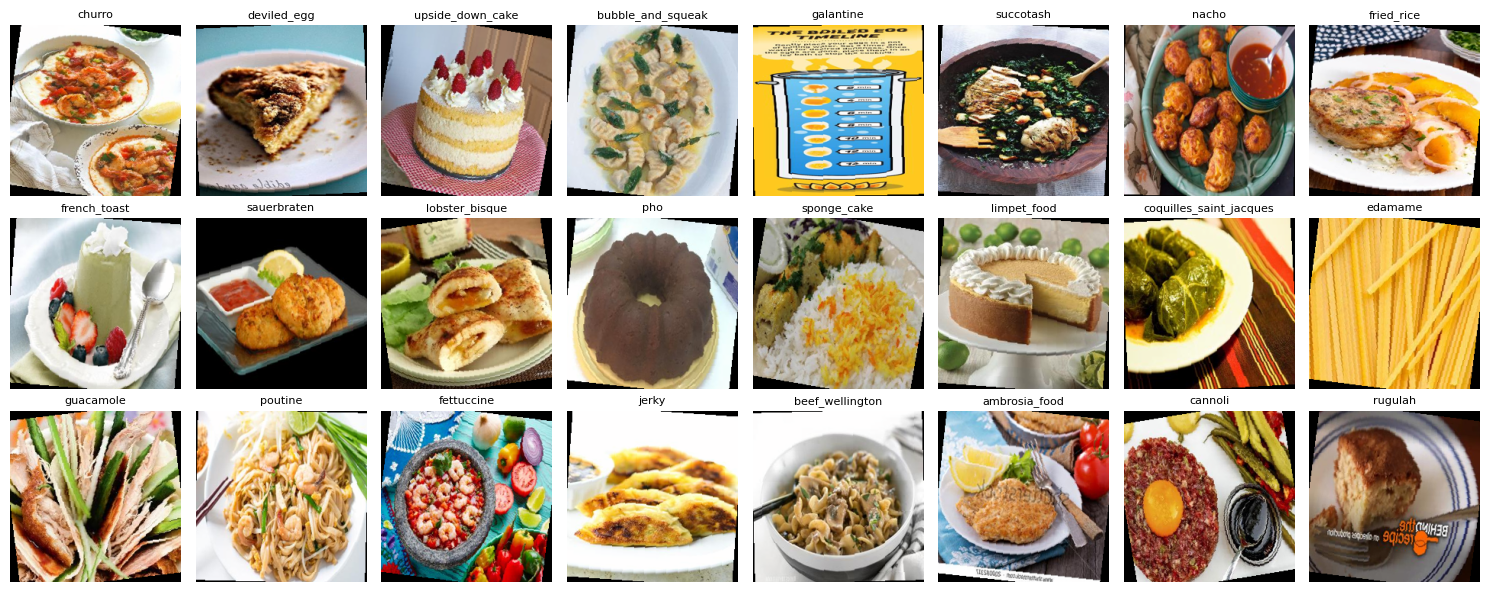

In [18]:
# plot some random augmented images 
plt.figure(figsize=(15, 6))

for i in range(24): 
    plt.subplot(3, 8, i + 1)
    
    rand_idx = np.random.randint(len(train_data))
    img, label = train_data.__getitem__(rand_idx)
    img = img.permute(1, 2, 0).numpy()

    #  denormalize
    img = glb_std * img + glb_mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    title_text = data_classes.iloc[label]['name']
    plt.title(title_text, fontsize=8)
    
    plt.axis('off')

plt.tight_layout()
plt.show()


In [16]:
# Add data loader 
BATCH_SIZE = 64 
PIN_MEMORY = True if device == 'cuda' or device == 'mps' else False
NUM_WORKERS = 0
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
print(f"There are \n {len(train_loader)} training batches \n {len(val_loader)} validation batches \n {len(test_loader)} testing batches")


There are 
 7 training batches 
 2 validation batches 
 0 testing batches


In [17]:
# inspired by vgg-16 
# https://arxiv.org/abs/1409.1556
"""
    The network architecture inspired by VGG-16 with following update
    1. Add Batch Normalization after each Convolution layer to have a faster convergance and more stable gradient 
    2. Add Dropout layer before classification layer to raiseeduces co-adaptation of neurons
    3. only 4 blocks while VGG-16 have 5 blocks
"""

class Net(nn.Module):
    
    def __init__(self):
        super().__init__() 
        self.conv_b1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ) 
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
            nn.Linear(512, 360),
            nn.ReLU(), 
            nn.Dropout(0.2),
            nn.Linear(360, NUM_CLASSES), 
        )

    def forward(self, x):   
        x = self.conv_b1(x)
        x = self.conv_b2(x)
        x = self.conv_b3(x)
        x = self.conv_b4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) 
        x = self.fc(x)
        return x
net = Net().to(device)
# log the total number of parameter
model_parameters = filter(lambda p: p.requires_grad, net.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(f'The model has {params} trainable parameters')


The model has 7915931 trainable parameters


In [21]:
summary(net, input_data=(3, 160, 160))

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 80, 80]          --
|    └─Conv2d: 2-1                       [-1, 64, 160, 160]        1,792
|    └─BatchNorm2d: 2-2                  [-1, 64, 160, 160]        128
|    └─ReLU: 2-3                         [-1, 64, 160, 160]        --
|    └─Conv2d: 2-4                       [-1, 64, 160, 160]        36,928
|    └─BatchNorm2d: 2-5                  [-1, 64, 160, 160]        128
|    └─ReLU: 2-6                         [-1, 64, 160, 160]        --
|    └─MaxPool2d: 2-7                    [-1, 64, 80, 80]          --
├─Sequential: 1-2                        [-1, 128, 40, 40]         --
|    └─Conv2d: 2-8                       [-1, 128, 80, 80]         73,856
|    └─BatchNorm2d: 2-9                  [-1, 128, 80, 80]         256
|    └─ReLU: 2-10                        [-1, 128, 80, 80]         --
|    └─Conv2d: 2-11                      [-1, 128, 80, 80]         147,

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 80, 80]          --
|    └─Conv2d: 2-1                       [-1, 64, 160, 160]        1,792
|    └─BatchNorm2d: 2-2                  [-1, 64, 160, 160]        128
|    └─ReLU: 2-3                         [-1, 64, 160, 160]        --
|    └─Conv2d: 2-4                       [-1, 64, 160, 160]        36,928
|    └─BatchNorm2d: 2-5                  [-1, 64, 160, 160]        128
|    └─ReLU: 2-6                         [-1, 64, 160, 160]        --
|    └─MaxPool2d: 2-7                    [-1, 64, 80, 80]          --
├─Sequential: 1-2                        [-1, 128, 40, 40]         --
|    └─Conv2d: 2-8                       [-1, 128, 80, 80]         73,856
|    └─BatchNorm2d: 2-9                  [-1, 128, 80, 80]         256
|    └─ReLU: 2-10                        [-1, 128, 80, 80]         --
|    └─Conv2d: 2-11                      [-1, 128, 80, 80]         147,

In [22]:

counts = Counter(trainable_pdf['label'])

weights = []
for c in range(251):
    weights.append(1.0 / np.sqrt(counts[c])) # SQRT applied to make it more softner instead of raw count

weights = torch.tensor(weights, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)
weight=weights.to(device)

In [ ]:
# Setup the model compiler
EPOCHS = 30
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)

# loss method 
loss_fun = nn.CrossEntropyLoss()
# per-epoch stepping
# scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


In [20]:
# Create a training method
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0 
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    if y.ndim == 2:
      y = y.squeeze(1)
    y = y.long()
    optimizer.zero_grad() # reset the gradient
    y_pred = model(X) # (B, C, H, W)
    loss = loss_fun(y_pred, y) # calculate the loss

    # Pixel level 
    loss.backward() # comput the gradient
    optimizer.step() # update the weight
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0) 
    
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total 
  return training_loss/len(dataloader), training_acc, 


In [21]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      if y.ndim == 2:
        y = y.squeeze(1)
      y = y.long()
      y_pred = model(X)
      loss = loss_fun(y_pred, y)
      val_loss += loss.item() 
      preds = torch.argmax(y_pred, dim=1)
      # accuracy in pixel level
      correct += (preds == y).sum().item()
      total += y.size(0)

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [26]:
for name, p in net.named_parameters():
    if p.grad is not None:
        print(name, p.grad.abs().mean())
        break

In [27]:
unique_labels = sorted(trainable_pdf['label'].unique())

print(len(unique_labels))
print(unique_labels[:10])
print(unique_labels[-10:])

251
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[241, 242, 243, 244, 245, 246, 247, 248, 249, 250]


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [], 
    "lr": [], 
}
best_val_loss = float('inf')

patience, epochs_no_improve = 10, 0
best_val_acc = 0
start_train_time = time.time()
for i in range(EPOCHS):
    print(f'Epoch {i+1}:')
    tr_loss, tr_acc = train_model(net, train_loader, loss_fun, optimizer)
    history['train_acc'].append(tr_acc)
    history['train_loss'].append(tr_loss) 
    # scheduler.step()

    val_loss, val_acc = validate_model(net, val_loader, loss_fun, i+1)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss) 
    history['lr'].append(optimizer.param_groups[-1]['lr'])
    

    print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] | lr [{optimizer.param_groups[-1]['lr']:.6f}]
    """)

    # Save only weights of the best model 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(net.state_dict(), 'best_model_weights.pth')
        print("Best model saved!")
    # else:
    #     epochs_no_improve += 1
    #     if epochs_no_improve >= patience:
    #         print(f"Early stopping at epoch {i+1}")
    #         break
torch.save(net.state_dict(), 'last_model.pth')
print(f'Last model saved correctly')
end_train_time = time.time()
print(f'End training after {(end_train_time - start_train_time)/60:.4f} minutes')

<Axes: >

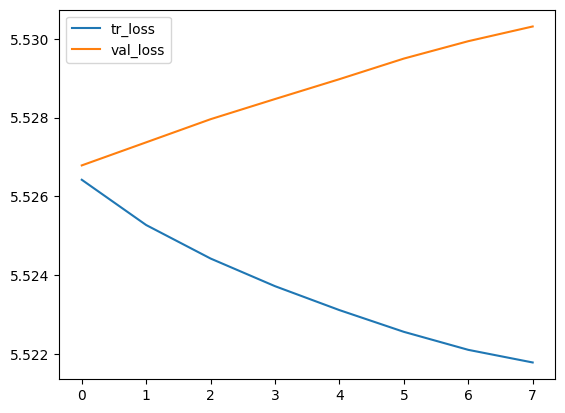

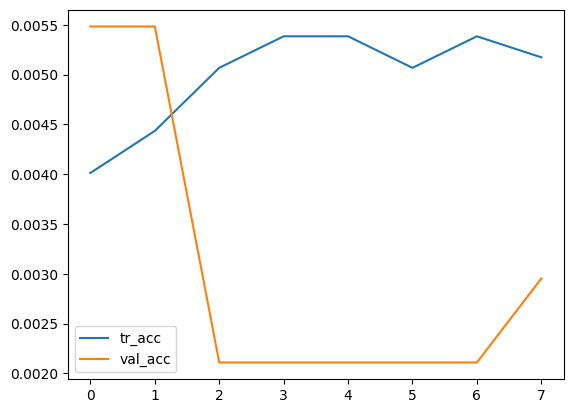

In [ ]:
# Plot the learning curve 
pd.DataFrame({'tr_loss': history['train_loss'], 'val_loss': history['val_loss']}).plot()
pd.DataFrame({'tr_acc': history['train_acc'], 'val_acc': history['val_acc']}).plot()